# Module Imports

In [20]:
import scipy.io as sio
import pandas as pd
import numpy as np
import os
import torch
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))

if project_root not in sys.path:

    sys.path.insert(0, project_root)

print("Project root:", project_root)

print(sys.path)

from data_classes.decomposition import Extract_Features
from data_classes.decomposition import Extract_Features
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch
import models.classification as classify
import models.loops as loops
import models.models as models
import librosa

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from torch.utils.data import DataLoader, Subset
import plotly.express as px
from IPython.display import display
import os

from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc,
    cohen_kappa_score
)

import io
import contextlib

from xgboost import XGBClassifier

Project root: /Users/kanwarsingh/Desktop/AI/acoustic_signal_classification
['/Users/kanwarsingh/Desktop/AI/acoustic_signal_classification', '/opt/homebrew/Cellar/python@3.13/3.13.1/Frameworks/Python.framework/Versions/3.13/lib/python313.zip', '/opt/homebrew/Cellar/python@3.13/3.13.1/Frameworks/Python.framework/Versions/3.13/lib/python3.13', '/opt/homebrew/Cellar/python@3.13/3.13.1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/lib-dynload', '', '/Users/kanwarsingh/Desktop/AI/acoustic_signal_classification/venv/lib/python3.13/site-packages', '/var/folders/nh/9fsl45m17nn6q_xt_zd0wwbw0000gn/T/tmp0z76i2yb']


# Loading Data

In [2]:
# load & preprocess
P2_data = sio.loadmat('../../data/phase2_data_20220215.mat')
P2_samples = pd.DataFrame(P2_data['x'].T)
P2_labels  = pd.DataFrame(P2_data['y'].T, columns=['y'])
P2_df = pd.concat([P2_samples, P2_labels], axis=1)
bad_indices = [
    100,303,496,507,609,706,909,1011,1113,1271,1373,1475,1577,1679,1781,1883,2085,2287,
    2389,2489,2789,2891,2895,2995,3096,3497,3767,3997,4099,4201,4499,4699,5199,5301,
    5302,5500,7688,7690,7691,7692,7696,7702,7704,7708,7715,7723,7727,7810,7841,7870,
    7888,7936,7941,7965,7997,8061,8080,8081,8095,8098,8124,8125,8126,8127,8128,8132,
    8156,8157,8158,8159,8160,8161,8215,8261,8302,8310,8322,8395,8425,8477,8478,8479,
    8483,8487,8491,8496,8527,8563,8587,8642,8743,8848,
    0,94,98,102,203,403,505,607,611,708,809,1009,1111,1171,1273,1473,1575,1579,1635,
    1660,1674,1681,1881,1983,1985,2087,2088,2187,2246,2387,2589,2689,2791,2893,3196,
    3455,3495,3696,3798,3999,4199,4701,4748,4749,4798,4999,5201,5209,5244,5245,5255,
    5924,5945,5977,6128,6135,6229,6271,6299,6377,6383,6388,6389,6678,6760,6903,6906,
    6935,6936,7430,7582,7694,7698,7699,7700,7706,7710,7713,7717,7718,7777,7778,7856,
    7872,7939,7943,7960,7984,7999,8046,8048,8059,8063,8064,8068,8078,8083,8084,8085,
    8093,8165,8166,8191,8308,8366,8397,8398,8481,8485,8489,8493,8494,8498,8544,8565,
    8640,8692,8798,8902
]

P2_df = P2_df.drop(index=bad_indices, errors='ignore')
P2_df = P2_df.dropna()

shuffled_df = P2_df.sample(frac=1, random_state=42).reset_index(drop=True)
P2_df_X = shuffled_df.iloc[:, :-1]
P2_df_Y = shuffled_df.iloc[:, -1]

In [3]:
P2_raw = Extract_Features(P2_df_X, P2_df_Y, feature='raw')
print(P2_raw.get_samples().shape, P2_raw.get_labels().shape)

(8229, 4800) (8229,)


## Data Distribution

### Full Dataset Distribution

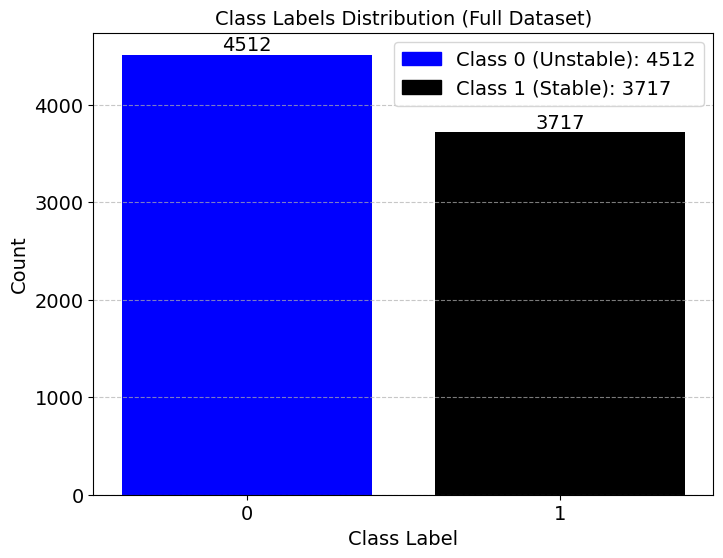

In [4]:
label_counts = P2_df_Y.value_counts().sort_index()

plt.figure(figsize=(8, 6))

colors = ['blue' if x == 0 else 'black' for x in label_counts.index]
bars = plt.bar(label_counts.index.astype(int), label_counts.values, color=colors)

plt.xlabel('Class Label', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Class Labels Distribution (Full Dataset)', fontsize=14)
plt.xticks(label_counts.index.astype(int), fontsize=14)
plt.yticks(fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# actual count on top of each bar
for bar, count in zip(bars, label_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(count),
        ha='center',
        va='bottom',
        fontsize=14
    )

# legend with actual counts
legend_elements = [
    Patch(facecolor='blue', edgecolor='blue', label=f'Class 0 (Unstable): {label_counts.get(0, 0)}'),
    Patch(facecolor='black', edgecolor='black', label=f'Class 1 (Stable): {label_counts.get(1, 0)}')
]
plt.legend(handles=legend_elements, fontsize=14)

plt.show()

### Train, Test, Val Distribution for Epoch cutoff

In [5]:
idx_all = np.arange(len(P2_raw))
y_all = np.array([P2_raw[i][1] for i in idx_all])

# 80% training, 20% temporary validation/test set
train_val_idx, val_test_idx = train_test_split(
    idx_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all

)

# Split the remaining 20% equally: 10% validation, 10% test

val_idx, test_idx = train_test_split(
    val_test_idx,
    test_size=0.5,
    random_state=42,
    stratify=y_all[val_test_idx]

)

In [6]:
# distribution of class labels in train, validation, and test sets
train_labels = y_all[train_val_idx]
val_labels = y_all[val_idx]
test_labels = y_all[test_idx]

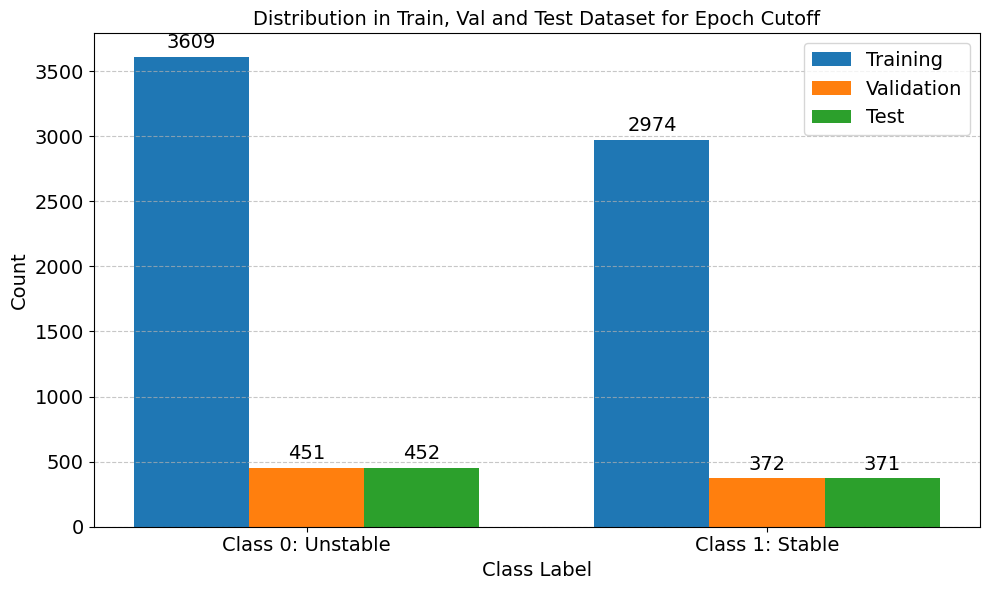

In [7]:
train_classes, train_counts = np.unique(train_labels, return_counts=True)
val_classes, val_counts = np.unique(val_labels, return_counts=True)
test_classes, test_counts = np.unique(test_labels, return_counts=True)

train_count_dict = dict(zip(train_classes, train_counts))
val_count_dict = dict(zip(val_classes, val_counts))
test_count_dict = dict(zip(test_classes, test_counts))

class_labels = [0, 1]

train_class_counts = [train_count_dict.get(0, 0), train_count_dict.get(1, 0)]
val_class_counts = [val_count_dict.get(0, 0), val_count_dict.get(1, 0)]
test_class_counts = [test_count_dict.get(0, 0), test_count_dict.get(1, 0)]

x = np.arange(len(class_labels))

bar_width = 0.25

plt.figure(figsize=(10, 6))
train_bars = plt.bar(x - bar_width, train_class_counts, width=bar_width, label="Training")
val_bars = plt.bar(x, val_class_counts, width=bar_width, label="Validation")
test_bars = plt.bar(x + bar_width, test_class_counts, width=bar_width, label="Test")

plt.xlabel("Class Label", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.title("Distribution in Train, Val and Test Dataset for Epoch Cutoff", fontsize=14)
plt.xticks(x, ["Class 0: Unstable", "Class 1: Stable"], fontsize=14)
plt.yticks(fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.7)

all_counts = train_class_counts + val_class_counts + test_class_counts
text_offset = max(all_counts) * 0.01

for bars in [train_bars, val_bars, test_bars]:
    for bar in bars:
        count = int(bar.get_height())
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + text_offset, str(count), ha="center", va="bottom", fontsize=14)

plt.legend(fontsize=14)
plt.tight_layout()
plt.show()


### Train and Test Distribution for Model Evaluation

In [8]:
idx_all = np.arange(len(P2_raw))
y_all = np.array([P2_raw[i][1] for i in idx_all])

train_idx, test_idx = train_test_split(
    idx_all,
    test_size=0.1,
    random_state=42,
    stratify=y_all
)

In [9]:
train_labels = y_all[train_idx]
test_labels = y_all[test_idx]

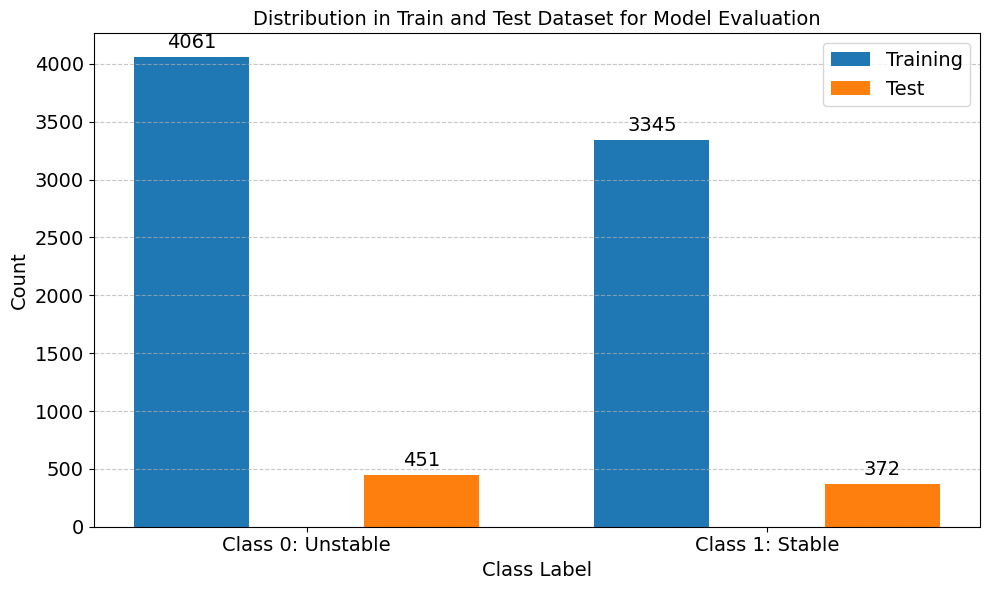

In [10]:
train_classes, train_counts = np.unique(train_labels, return_counts=True)
test_classes, test_counts = np.unique(test_labels, return_counts=True)

train_count_dict = dict(zip(train_classes, train_counts))
test_count_dict = dict(zip(test_classes, test_counts))

class_labels = [0, 1]

train_class_counts = [train_count_dict.get(0, 0), train_count_dict.get(1, 0)]
test_class_counts = [test_count_dict.get(0, 0), test_count_dict.get(1, 0)]

x = np.arange(len(class_labels))

bar_width = 0.25

plt.figure(figsize=(10, 6))
train_bars = plt.bar(x - bar_width, train_class_counts, width=bar_width, label="Training")
test_bars = plt.bar(x + bar_width, test_class_counts, width=bar_width, label="Test")

plt.xlabel("Class Label", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.title("Distribution in Train and Test Dataset for Model Evaluation", fontsize=14)
plt.xticks(x, ["Class 0: Unstable", "Class 1: Stable"], fontsize=14)
plt.yticks(fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.7)

all_counts = train_class_counts + test_class_counts
text_offset = max(all_counts) * 0.01

for bars in [train_bars, test_bars]:
    for bar in bars:
        count = int(bar.get_height())
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + text_offset, str(count), ha="center", va="bottom", fontsize=14)

plt.legend(fontsize=14)
plt.tight_layout()
plt.show()


## Prepare ROC Dataframe

In [11]:
roc_df = pd.DataFrame(columns=[
    "model_name",
    "model",
    "ev_pct",
    "hidden",
    "accuracy",
    "roc_auc",
    "fpr",
    "tpr",
    "roc_thresholds",
    "cohen_kappa"
])

roc_df

,model_name,model,ev_pct,hidden,accuracy,roc_auc,fpr,tpr,roc_thresholds,cohen_kappa


# Classical Experiments

In [40]:
# === PCA EV sweep with fixed nb_hidden {256,128,64,32} + loops.train/test + Plotly ===
torch.manual_seed(42)
np.random.seed(42)

explained_variances = [0.80, 0.85, 0.90, 0.95, 0.96, 0.97, 0.98, 0.99]
hidden_grid = [128, 64, 32]   # fixed hidden sizes
batch_size = 32
epochs = 20
model_dir = "./final_model_paths"
os.makedirs(model_dir, exist_ok=True)

y_all = P2_df_Y.squeeze().astype(int).values
idx_all = np.arange(len(y_all))
train_idx, test_idx = train_test_split(
    idx_all, test_size=0.1, random_state=42, stratify=y_all
)

results = []

device_str = "cuda" if torch.cuda.is_available() else (
    "mps" if torch.backends.mps.is_available() else "cpu"
)

def get_input_dim(X: np.ndarray) -> int:
    # Scalar feature count even if features are not strictly 2D
    return int(np.prod(X.shape[1:]))

for ev in explained_variances:
    # PCA features via Extract_Features
    P2_PCA = Extract_Features(P2_df_X, P2_df_Y, feature="pca", explained_variance=ev)

    # Torch datasets for loops
    full_ds = P2_PCA
    train_ds = Subset(full_ds, train_idx.tolist())
    test_ds  = Subset(full_ds, test_idx.tolist())

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, drop_last=False)

    # Numpy arrays for SVM + meta
    X = P2_PCA.get_samples()
    y = P2_PCA.get_labels().squeeze().astype(int)
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    input_dim = get_input_dim(X_train)
    num_classes = int(np.unique(y_all).size)

    # SVM baseline
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    svm = SVC(kernel="rbf", C=100, gamma="scale", random_state=42)
    svm.fit(X_train_s, y_train)
    svm_acc = accuracy_score(y_test, svm.predict(X_test_s))

    results.append({
        "explained_variance": int(ev * 100),
        "model": "SVM (RBF)",
        "nb_hidden": "—",
        "accuracy": svm_acc * 100,   # store as percentage number
        "input_dim": input_dim,
        "hidden_layers": "—"
    })

    # Only MLP 2-layer and 3-layer
    for h in hidden_grid:


        common_kwargs = {
            "nb_hidden": int(h),
            "input_dim": int(input_dim),
            "output_dim": int(num_classes),
            "dropout_rate": 0.2
        }

        mlp_runs = [
            ("MLP", "MLP (1-layer)", "mlp1", [h]),
            ("MLP_2_layer", "MLP (2-layer)", "mlp2", [h, h // 2]),
            ("MLP_3_layer", "MLP (3-layer)", "mlp3", [h, h // 2, h // 4]),
        ]

        for ctor_name, pretty, tag, hidden_list in mlp_runs:
            model_ctor = globals().get(ctor_name, getattr(classify, ctor_name))
            model = model_ctor(**common_kwargs)

            model_path = os.path.join(model_dir, f"{tag}_ev{int(ev*100)}_h{h}_P1.pth")

            # Train
            buf = io.StringIO()
            with contextlib.redirect_stdout(buf):
                loops.train(
                    model=model,
                    model_path=model_path,
                    train_loader=train_loader,
                    val=False,
                    val_loader=None,
                    batch_size=batch_size,
                    lr=1e-3,
                    weight_decay=0,
                    optim="adam",
                    epochs=epochs,
                )


            # Test
            buf = io.StringIO()
            with contextlib.redirect_stdout(buf):
                test_results = loops.test(
                    model=model,
                    model_path=model_path,
                    test_loader=test_loader,
                    report=False,
                    score=True,
                    device=device_str
                )

            acc = test_results["accuracy"]

            results.append({
                "explained_variance": int(ev * 100),
                "model": pretty,
                "nb_hidden": str(h),
                "accuracy": acc * 100,
                "input_dim": input_dim,
                "hidden_layers": f"H={hidden_list}"
            })
    print(f"Finished explained variance = {int(ev * 100)}")

# ---- Results & Plot ----
df_res = (
    pd.DataFrame(results)
    .sort_values(["explained_variance", "model", "nb_hidden"])
    .reset_index(drop=True)
)

# # ---- Figure dataframe (exclude MLP 1-layer only from plot) ----
# df_plot = df_res[df_res["model"] != "MLP (1-layer)"].copy()

fig = px.line(
    df_res,
    x="explained_variance",
    y="accuracy",
    color="model",
    line_dash="nb_hidden",
    markers=True,
    title="Explained Variance vs Accuracy — SVM & MLP Variants (Hidden sizes: 128, 64, 32)",
    labels={
        "explained_variance": "PCA Explained Variance (%)",
        "accuracy": "Accuracy (%)",
        "model": "Classifier",
        "nb_hidden": "Hidden width (1st layer)",
    },
    hover_data={"input_dim": True, "hidden_layers": True, "accuracy": ":.2f"}
)

fig.update_layout(
    hovermode="x unified",
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis=dict(
        automargin=True,
        showgrid=False,
        showline=True,
        linecolor="black",
        linewidth=1,
        mirror=True,
        ticks="outside",
        ticklen=6,
        tickwidth=1,
        tickcolor="black"
    ),
    yaxis=dict(
        automargin=True,
        showgrid=False,
        showline=True,
        linecolor="black",
        linewidth=1,
        mirror=True,
        ticks="outside",
        ticklen=6,
        tickwidth=1,
        tickcolor="black"
    )
)

# ---- Save figure ----
save_dir = "../../assets/phase2_report_assets"
os.makedirs(save_dir, exist_ok=True)

png_path = os.path.join(save_dir, "pca_ev_sweep_accuracy_p2.png")
html_path = os.path.join(save_dir, "pca_ev_sweep_accuracy_p2.html")

fig.write_html(html_path)
fig.write_image(png_path, width=1400, height=800, scale=2)

print(f"Saved interactive figure to: {html_path}")
print(f"Saved static figure to: {png_path}")

fig.show()

pd.set_option("display.max_rows", None)
display(df_res)

Finished explained variance = 80
Finished explained variance = 85
Finished explained variance = 90
Finished explained variance = 95
Finished explained variance = 96
Finished explained variance = 97
Finished explained variance = 98
Finished explained variance = 99
Saved interactive figure to: ../../assets/phase2_report_assets/pca_ev_sweep_accuracy_p2.html
Saved static figure to: ../../assets/phase2_report_assets/pca_ev_sweep_accuracy_p2.png


,explained_variance,model,nb_hidden,accuracy,input_dim,hidden_layers
0,80,MLP (1-layer),128,76.913730,99,H=[128]
1,80,MLP (1-layer),32,75.577157,99,H=[32]
2,80,MLP (1-layer),64,75.091130,99,H=[64]
3,80,MLP (2-layer),128,74.605103,99,"H=[128, 64]"
4,80,MLP (2-layer),32,75.820170,99,"H=[32, 16]"
5,80,MLP (2-layer),64,75.698663,99,"H=[64, 32]"
6,80,MLP (3-layer),128,73.876063,99,"H=[128, 64, 32]"
7,80,MLP (3-layer),32,74.119077,99,"H=[32, 16, 8]"
8,80,MLP (3-layer),64,72.539490,99,"H=[64, 32, 16]"
9,80,SVM (RBF),—,75.334143,99,—


## PCA + MLP

[RETRAIN] EV=96%, model=MLP (2-layer), nb_hidden=128
[RETRAIN] Saving checkpoint to -> ./final_model_paths/mlp2_ev96_h128_P2_RETRAIN.pth
[RETRAIN] model_name key -> mlp2_ev96_h128_P2_RETRAIN
[INFO] Testing the model
Test accuracy (threshold=0.50): 0.7995


/Users/kanwarsingh/Desktop/AI/acoustic_signal_classification/models/loops.py:309: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=14)


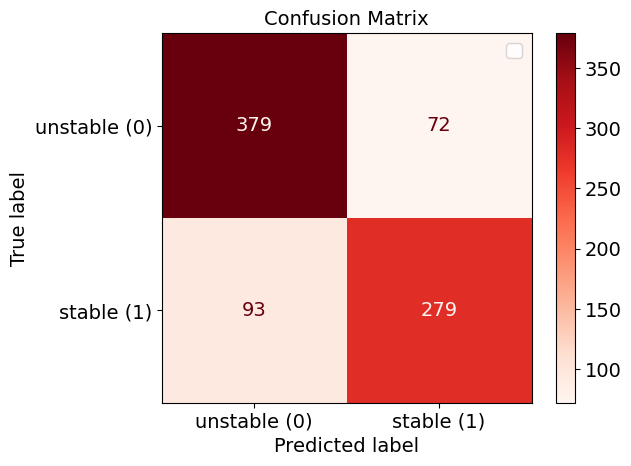

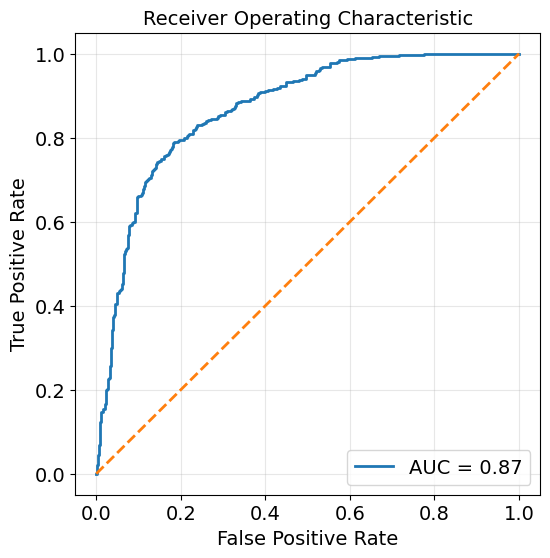


Classification Report (threshold = 0.50):

              precision    recall  f1-score   support

unstable (0)       0.80      0.84      0.82       451
  stable (1)       0.79      0.75      0.77       372

    accuracy                           0.80       823
   macro avg       0.80      0.80      0.80       823
weighted avg       0.80      0.80      0.80       823



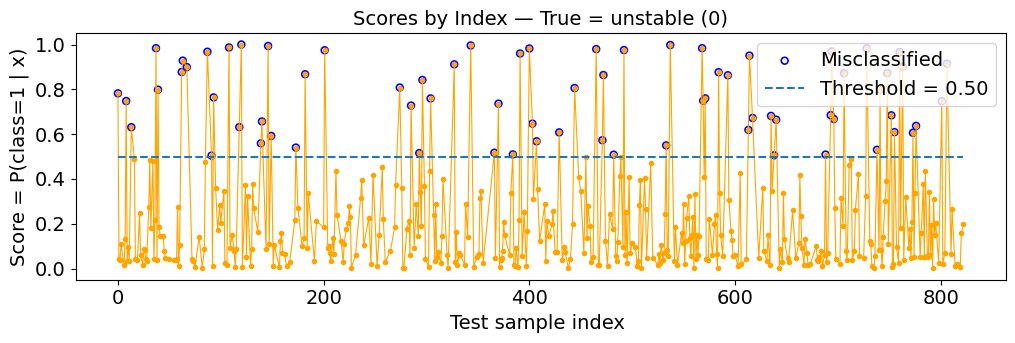

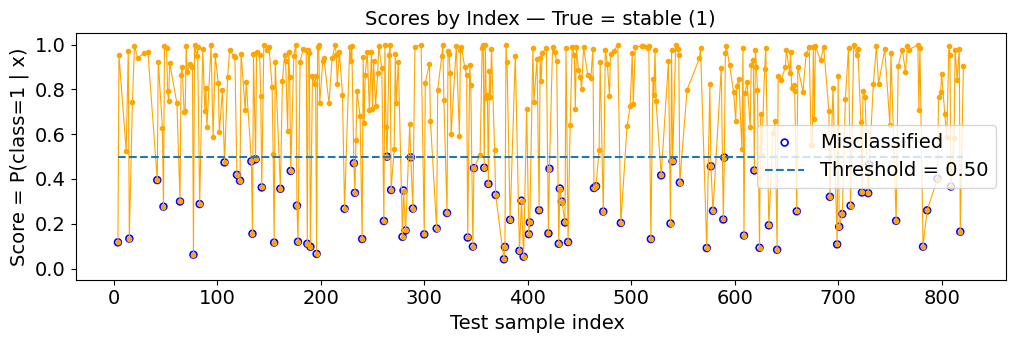

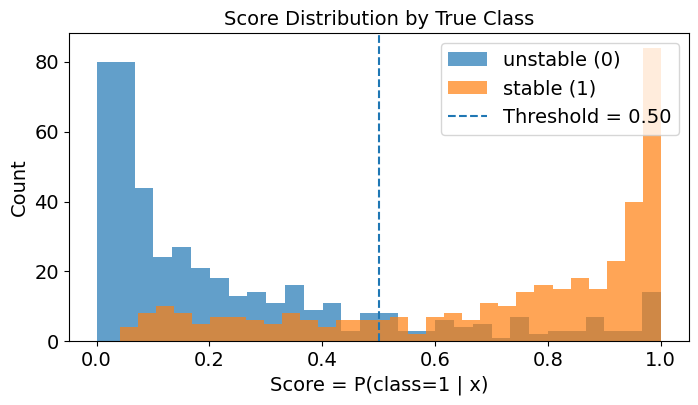

[RETRAIN] Accuracy: 0.7995
[RETRAIN] ROC AUC: 0.8713


In [25]:
# ----------------- HARD-CODED WINNER -----------------
BEST_EV_PCT     = 96
BEST_MODEL_NAME = "MLP (2-layer)"   # "MLP (1-layer)" | "MLP (2-layer)" | "MLP (3-layer)"
BEST_HIDDEN     = 128              # 128 | 64 | 32
# -----------------------------------------------------

device_str = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")

# Recreate mappings
pretty_to_ctor = {
    "MLP (1-layer)": "MLP",
    "MLP (2-layer)": "MLP_2_layer",
    "MLP (3-layer)": "MLP_3_layer",
}
ctor_to_tag = {"MLP": "mlp1", "MLP_2_layer": "mlp2", "MLP_3_layer": "mlp3"}

ctor_name = pretty_to_ctor[BEST_MODEL_NAME]
tag = ctor_to_tag[ctor_name]

# Unique model id used as key in roc_df
model_name = f"{tag}_ev{int(BEST_EV_PCT)}_h{int(BEST_HIDDEN)}_P2_RETRAIN"

# Output dirs/paths
model_dir = "./final_model_paths"
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, f"{model_name}.pth")

print(f"[RETRAIN] EV={BEST_EV_PCT}%, model={BEST_MODEL_NAME}, nb_hidden={BEST_HIDDEN}")
print(f"[RETRAIN] Saving checkpoint to -> {model_path}")
print(f"[RETRAIN] model_name key -> {model_name}")

# --- PCA dataset for the chosen EV
best_ev = BEST_EV_PCT / 100.0
P2_PCA_best = Extract_Features(
    P2_df_X,
    P2_df_Y,
    feature="pca",
    explained_variance=best_ev
)

# Split (same seed/stratify as before)
y_all = P2_df_Y.squeeze().astype(int).values
idx_all = np.arange(len(y_all))
train_idx, test_idx = train_test_split(
    idx_all,
    test_size=0.1,
    random_state=42,
    stratify=y_all
)

# Torch loaders
full_ds = P2_PCA_best
train_ds = Subset(full_ds, train_idx.tolist())
test_ds = Subset(full_ds, test_idx.tolist())

batch_size = 30
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, drop_last=False)

# Infer dims
X_best = P2_PCA_best.get_samples()
input_dim = int(np.prod(X_best.shape[1:]))
num_classes = int(np.unique(y_all).size)

# Instantiate the winning architecture from models/classification.py
common_kwargs = {
    "nb_hidden": int(BEST_HIDDEN),
    "input_dim": int(input_dim),
    "output_dim": int(num_classes),
    "dropout_rate": 0.2,
}
model_ctor = globals().get(ctor_name, getattr(classify, ctor_name))
model = model_ctor(**common_kwargs)

# ----------------- TRAIN -----------------
epochs = 20

buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    loops.train(
        model=model,
        model_path=model_path,
        train_loader=train_loader,
        val=False,
        val_loader=None,
        batch_size=batch_size,
        lr=1e-3,
        weight_decay=0,
        optim="adam",
        epochs=epochs,
    )

# ----------------- TEST -----------------

test_results = loops.test(
    model=model,
    model_path=model_path,
    test_loader=test_loader,
    report=True,
    score=True,
    device=device_str,
    threshold_viz=True
)

acc = test_results["accuracy"]
roc_auc = test_results["roc_auc"]
fpr = test_results["fpr"]
tpr = test_results["tpr"]
roc_thresholds = test_results["roc_thresholds"]
cohen_kappa = test_results["cohen_kappa"]

print(f"[RETRAIN] Accuracy: {acc:.4f}")
print(f"[RETRAIN] ROC AUC: {roc_auc:.4f}")

# ----------------- UPSERT ROC VALUES INTO DATAFRAME -----------------
new_row = pd.DataFrame([{
    "model_name": model_name,                 # unique key
    "model": BEST_MODEL_NAME,                # pretty display name
    "ev_pct": BEST_EV_PCT,
    "hidden": BEST_HIDDEN,
    "accuracy": acc,
    "roc_auc": roc_auc,
    "fpr": np.array(fpr),
    "tpr": np.array(tpr),
    "roc_thresholds": np.array(roc_thresholds),
    "cohen_kappa": cohen_kappa
}])

# remove old row with same unique key, then append new one
roc_df = roc_df[roc_df["model_name"] != model_name]
roc_df = pd.concat([roc_df, new_row], ignore_index=True)

if model_name == "mlp2_ev96_h256_P2_RETRAIN":
    roc_df = roc_df[roc_df["model_name"] != "mlp2_ev96_h128_P2_RETRAIN"]
else:
    roc_df = roc_df[roc_df["model_name"] != "mlp2_ev96_h256_P2_RETRAIN"]


### PCA MLP Graph

[GRAPH] Saved to: ../assets/march_paper/best_model_mlp2_ev96_h128_P2_RETRAIN.png (and/or .pdf)


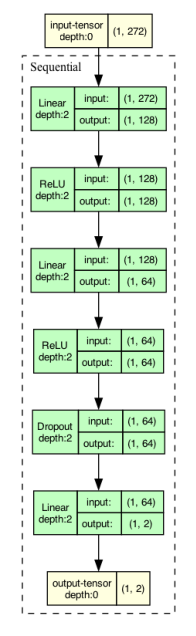

In [ ]:

# ----------------- DRAW GRAPH -----------------
import shutil as _shutil
dot = _shutil.which("dot") or "/opt/homebrew/bin/dot"
if not os.path.exists(dot):
    dot = "/usr/local/bin/dot"
os.environ["GRAPHVIZ_DOT"] = dot
os.environ["PATH"] += os.pathsep + os.path.dirname(dot)

from torchview import draw_graph

model.eval()
graph_fname = f"../assets/march_paper/best_model_{model_name}"
graph = draw_graph(
    model,
    input_size=(1, input_dim),  # MLP expects (batch, features)
    expand_nested=True,
    device="cpu",
    save_graph=True,
    filename=graph_fname,
)


print(f"[GRAPH] Saved to: {graph_fname}.png (and/or .pdf)")

# show graph in notebook
from PIL import Image
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
img_path = f"{graph_fname}.png"
if os.path.exists(img_path):
    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis("off")
    plt.show()
else:
    print(f"Graph image not found at {img_path}")

## PCA + SVM

Accuracy: 0.7886


/var/folders/nh/9fsl45m17nn6q_xt_zd0wwbw0000gn/T/ipykernel_70538/1495000808.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=14)


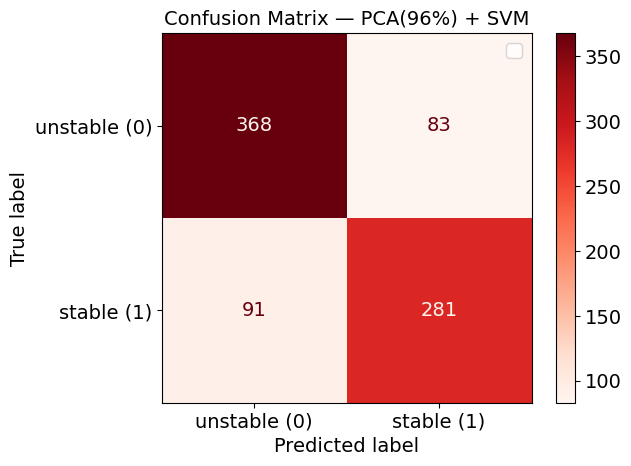


Classification Report:

              precision    recall  f1-score   support

unstable (0)       0.80      0.82      0.81       451
  stable (1)       0.77      0.76      0.76       372

    accuracy                           0.79       823
   macro avg       0.79      0.79      0.79       823
weighted avg       0.79      0.79      0.79       823

ROC AUC: 0.8504


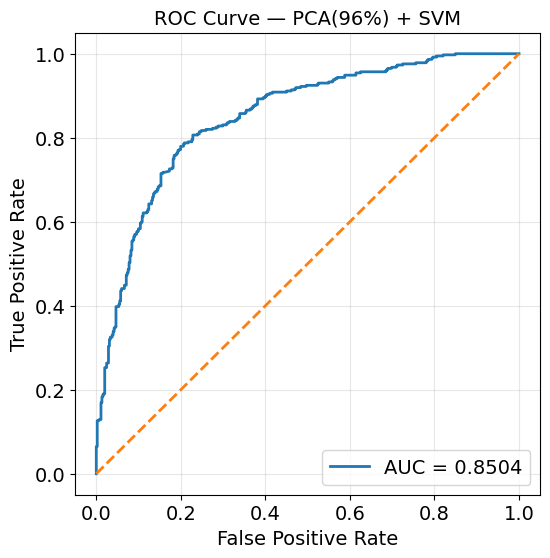

,model_name,model,ev_pct,hidden,accuracy,roc_auc,fpr,tpr,roc_thresholds,cohen_kappa
0,mlp2_ev96_h128_P2_RETRAIN,MLP (2-layer),96,128,0.788578,0.866891,"[0.0, 0.0022172949002217295, 0.002217294900221...","[0.0, 0.0, 0.005376344086021506, 0.00537634408...","[inf, 0.9999014, 0.9996251, 0.99941456, 0.9986...",0.575622
1,svm_rbf_pca_ev96,SVM (RBF),96,-,0.788578,0.850383,"[0.0, 0.0, 0.0, 0.0022172949002217295, 0.00221...","[0.0, 0.002688172043010753, 0.0645161290322580...","[inf, 0.9945706268158228, 0.9651473050712376, ...",0.572419


In [ ]:
# === Retrain + Test using the hard-coded best combo, then draw graph ===
torch.manual_seed(42)
np.random.seed(42)


# ----------------- HARD-CODED WINNER -----------------
BEST_EV_PCT     = 96
BEST_MODEL_NAME = "SVM (RBF)"

# -----------------------------------------------------
np.random.seed(42)
# -----------------------------
# Data
# -----------------------------
X = P2_df_X.to_numpy()
y = P2_df_Y.squeeze().astype(int).to_numpy() if hasattr(P2_df_Y, "to_numpy") else P2_df_Y.squeeze().astype(int).values



X_train = X[train_idx]
X_test = X[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

# flatten if needed
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_test_2d = X_test.reshape(X_test.shape[0], -1)

svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=BEST_EV_PCT / 100.0, random_state=42)),
    ("svm", SVC(
        kernel="rbf",
        C=100,
        gamma="scale",
        probability=True,
        random_state=42
    ))
])

svm_pipe.fit(X_train_2d, y_train)

y_pred = svm_pipe.predict(X_test_2d)
y_score = svm_pipe.predict_proba(X_test_2d)[:, 1]

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

plt.rcParams.update({'font.size': 14})
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["unstable (0)", "stable (1)"]
)
disp.plot(cmap="Reds", values_format=".0f")
plt.title(f"Confusion Matrix — PCA({BEST_EV_PCT}%) + SVM", fontsize=14)
plt.xlabel("Predicted label", fontsize=14)
plt.ylabel("True label", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.show()

report = classification_report(
    y_test,
    y_pred,
    target_names=["unstable (0)", "stable (1)"],
    zero_division=0
)
print("\nClassification Report:\n")
print(report)

fpr, tpr, roc_thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

print(f"ROC AUC: {roc_auc:.4f}")

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], lw=2, linestyle="--")
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title(f"ROC Curve — PCA({BEST_EV_PCT}%) + SVM", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(loc="lower right", fontsize=14)
plt.grid(alpha=0.3)
plt.show()

roc_values_df = pd.DataFrame({
    "fpr": fpr,
    "tpr": tpr,
    "roc_threshold": roc_thresholds
})

model_name = f"svm_rbf_pca_ev{BEST_EV_PCT}"

new_row = pd.DataFrame([{
    "model_name": model_name,
    "model": "SVM (RBF)",
    "ev_pct": BEST_EV_PCT,
    "hidden": "-",
    "accuracy": acc,
    "roc_auc": roc_auc,
    "fpr": np.array(fpr),
    "tpr": np.array(tpr),
    "roc_thresholds": np.array(roc_thresholds),
    "cohen_kappa": cohen_kappa_score(y_test, y_pred)
}])

if "roc_df" not in globals():
    roc_df = pd.DataFrame(columns=[
        "model_name",
        "model",
        "ev_pct",
        "hidden",
        "accuracy",
        "roc_auc",
        "fpr",
        "tpr",
        "roc_thresholds",
    ])

roc_df = roc_df[roc_df["model_name"] != model_name]
roc_df = pd.concat([roc_df, new_row], ignore_index=True)


In [16]:
display(roc_df)

,model_name,model,ev_pct,hidden,accuracy,roc_auc,fpr,tpr,roc_thresholds,cohen_kappa
0,mlp2_ev96_h128_P2_RETRAIN,MLP (2-layer),96,128,0.788578,0.866891,"[0.0, 0.0022172949002217295, 0.002217294900221...","[0.0, 0.0, 0.005376344086021506, 0.00537634408...","[inf, 0.9999014, 0.9996251, 0.99941456, 0.9986...",0.575622
1,svm_rbf_pca_ev96,SVM (RBF),96,-,0.788578,0.850383,"[0.0, 0.0, 0.0, 0.0022172949002217295, 0.00221...","[0.0, 0.002688172043010753, 0.0645161290322580...","[inf, 0.9945706268158228, 0.9651473050712376, ...",0.572419
2,mlp2_ev96_h256_P2_RETRAIN,MLP (2-layer),96,256,0.808019,0.876028,"[0.0, 0.0, 0.0, 0.0022172949002217295, 0.00221...","[0.0, 0.002688172043010753, 0.0483870967741935...","[inf, 0.9996388, 0.99283, 0.99258476, 0.990600...",0.611554


## PCA + XGB


Accuracy: 0.8068


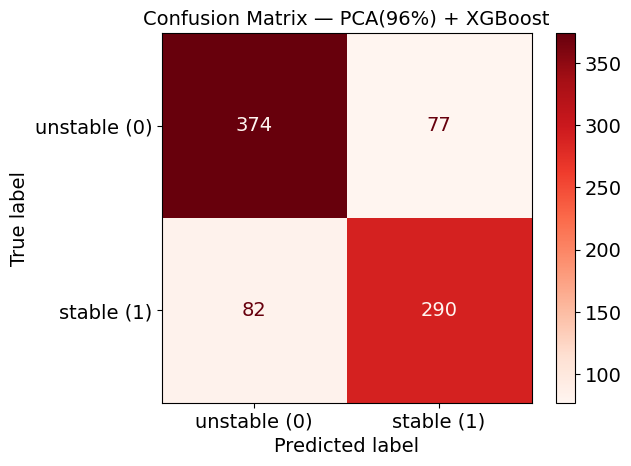


Classification Report:

              precision    recall  f1-score   support

unstable (0)       0.82      0.83      0.82       451
  stable (1)       0.79      0.78      0.78       372

    accuracy                           0.81       823
   macro avg       0.81      0.80      0.80       823
weighted avg       0.81      0.81      0.81       823

ROC AUC: 0.8842


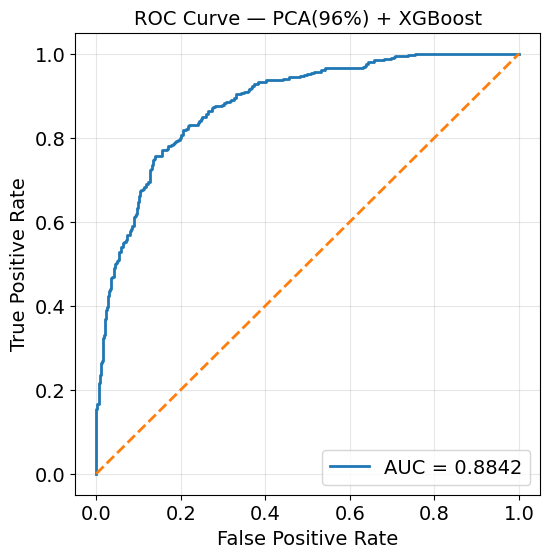

In [21]:

torch.manual_seed(42)
np.random.seed(42)

BEST_EV_PCT = 96
BEST_MODEL_NAME = "XGBoost"

np.random.seed(42)

# -----------------------------
# Data
# -----------------------------
X = P2_df_X.to_numpy()
y = P2_df_Y.squeeze().astype(int).to_numpy() if hasattr(P2_df_Y, "to_numpy") else P2_df_Y.squeeze().astype(int).values

X_train = X[train_idx]
X_test = X[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

# Flatten if needed
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_test_2d = X_test.reshape(X_test.shape[0], -1)

xgb_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=BEST_EV_PCT / 100.0, random_state=42)),
    ("xgb", XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipe.fit(X_train_2d, y_train)

y_pred = xgb_pipe.predict(X_test_2d)
y_score = xgb_pipe.predict_proba(X_test_2d)[:, 1]

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

plt.rcParams.update({"font.size": 14})
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["unstable (0)", "stable (1)"]
)
disp.plot(cmap="Reds", values_format=".0f")
plt.title(f"Confusion Matrix — PCA({BEST_EV_PCT}%) + XGBoost", fontsize=14)
plt.xlabel("Predicted label", fontsize=14)
plt.ylabel("True label", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

report = classification_report(
    y_test,
    y_pred,
    target_names=["unstable (0)", "stable (1)"],
    zero_division=0
)
print("\nClassification Report:\n")
print(report)

fpr, tpr, roc_thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

print(f"ROC AUC: {roc_auc:.4f}")

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], lw=2, linestyle="--")
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title(f"ROC Curve — PCA({BEST_EV_PCT}%) + XGBoost", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(loc="lower right", fontsize=14)
plt.grid(alpha=0.3)
plt.show()

roc_values_df = pd.DataFrame({
    "fpr": fpr,
    "tpr": tpr,
    "roc_threshold": roc_thresholds
})

model_name = f"xgboost_pca_ev{BEST_EV_PCT}"

new_row = pd.DataFrame([{
    "model_name": model_name,
    "model": "XGBoost",
    "ev_pct": BEST_EV_PCT,
    "hidden": "-",
    "accuracy": acc,
    "roc_auc": roc_auc,
    "fpr": np.array(fpr),
    "tpr": np.array(tpr),
    "roc_thresholds": np.array(roc_thresholds),
    "cohen_kappa": cohen_kappa_score(y_test, y_pred)
}])

if "roc_df" not in globals():
    roc_df = pd.DataFrame(columns=[
        "model_name",
        "model",
        "ev_pct",
        "hidden",
        "accuracy",
        "roc_auc",
        "fpr",
        "tpr",
        "roc_thresholds",
        "cohen_kappa"
    ])

roc_df = roc_df[roc_df["model_name"] != model_name]
roc_df = pd.concat([roc_df, new_row], ignore_index=True)

In [26]:
display(roc_df)

,model_name,model,ev_pct,hidden,accuracy,roc_auc,fpr,tpr,roc_thresholds,cohen_kappa
0,svm_rbf_pca_ev96,SVM (RBF),96,-,0.788578,0.850383,"[0.0, 0.0, 0.0, 0.0022172949002217295, 0.00221...","[0.0, 0.002688172043010753, 0.0645161290322580...","[inf, 0.9945706268158228, 0.9651473050712376, ...",0.572419
1,xgboost_pca_ev96,XGBoost,96,-,0.806804,0.884248,"[0.0, 0.0, 0.0, 0.0022172949002217295, 0.00221...","[0.0, 0.002688172043010753, 0.1532258064516129...","[inf, 0.9946602, 0.94405866, 0.9435143, 0.9386...",0.609556
3,mlp2_ev96_h128_P2_RETRAIN,MLP (2-layer),96,128,0.799514,0.871307,"[0.0, 0.0022172949002217295, 0.002217294900221...","[0.0, 0.0, 0.021505376344086023, 0.02150537634...","[inf, 0.99998486, 0.9977969, 0.9977094, 0.9960...",0.593288
